# Data Scraping

This notebook contains code to scrap data on weather, UK bank holidays and covid times etc. The notebook also formats the data before modelling.

Different datasets need to be collected, cleaned and joined:

Variable | Unit | Description | Source
---------|------|----------|----------
Estimated Actual Footfall | | Number of visitors in area for a given day. | [HUQ](https://huq.io/insights/footfall-data/)
Estimated Actual Footfall Rolling | | Average number of visitors of the previous 6 days for the same day of the week in area | [HUQ](https://huq.io/insights/footfall-data/)
footfal_lag_1 | | Footfall on previous day |
footfal_lag_7 | | Footfall on that weekday in the previous week |
footfal_lag_14 | | Footfall on that weekday 2 weeks previous |
roll_mean_7 | | Average footfall in the previous 7 days |
roll_std_7 | |  Standard deviation of footfall in the previous 7 days |
Cos_weekday_num| |Cosine of the week day number | 
Sin_weekday_num| |Sinus of the week day number | 
Cos_month_num| |  Cosine of the month number| 
Sin_month_num| | Sinus of the month number| 
Cos_week_of_year| | Cosine of the week of year number| 
Sin_week_of_year| | Sinus of the week of year number | 
Year| | | 
bank_hol| |Whether or not that day is a bank holiday (0= No, 1= Yes)|[Kaggle](https://www.kaggle.com/datasets/shivd24coder/uk-national-holidays-dataset)
school_hol| |Whether or not that day is a school holiday (0= No, 1= Yes)|[Bradford Council](https://bradford.gov.uk/)
Covid times| |Whether or not that day was during covid restrictions (0= No, 1= Yes)|
Precipitation | mm | Sum of daily precipitation (including rain, showers and snowfall) | [Open Meteo API](https://open-meteo.com/en/docs/historical-weather-api?bounding_box=-90,-180,90,180&hourly=&daily=temperature_2m_mean,precipitation_sum,wind_speed_10m_max)
Temperature | °C | Average daily air temperature at 2 meters above ground | [Open Meteo API](https://open-meteo.com/en/docs/historical-weather-api?bounding_box=-90,-180,90,180&hourly=&daily=temperature_2m_mean,precipitation_sum,wind_speed_10m_max)
Wind Speed | km/h | Maximum wind speed on a day | [Open Meteo API](https://open-meteo.com/en/docs/historical-weather-api?bounding_box=-90,-180,90,180&hourly=&daily=temperature_2m_mean,precipitation_sum,wind_speed_10m_max)
Daylight Duration | seconds | Number of seconds of daylight per day | [Open Meteo API](https://open-meteo.com/en/docs/historical-weather-api?bounding_box=-90,-180,90,180&hourly=&daily=temperature_2m_mean,precipitation_sum,wind_speed_10m_max)

In [384]:
pip install matplotlib geopandas numpy

Note: you may need to restart the kernel to use updated packages.


In [385]:
#Import packages
import pandas as pd
import seaborn as sns
import matplotlib
import geopandas as gpd
import numpy as np

In [386]:
#Load footfall data
footfall = pd.read_csv(r"C:\Users\qxnq723\Desktop\Project 1\Coding\Analysis - All areas\footfall_Mix_Clean")
footfall.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10153 entries, 0 to 10152
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         10153 non-null  int64  
 1   area                               10153 non-null  object 
 2   datestamp                          10153 non-null  object 
 3   estimated_actual_footfall          9989 non-null   float64
 4   estimated_actual_footfall_rolling  2470 non-null   float64
 5   year                               10153 non-null  int64  
 6   month                              10153 non-null  int64  
 7   monthday                           10153 non-null  int64  
 8   weekday                            10153 non-null  int64  
 9   week_of_year                       10153 non-null  int64  
 10  Sin_weekday                        10153 non-null  float64
 11  Cos_weekday                        10153 non-null  flo

In [387]:
#Convert datestamp to datetime
footfall['datestamp'] = pd.to_datetime(footfall['datestamp'])

## Weekends

In [388]:
#Create binary on whether day is a Saturday or Sunday
weekend = {5, 6}
#Add column in footfall data (1= weekend, 0= normal day)
footfall['is_weekend'] = footfall['weekday'].isin(weekend).astype(int)
#Check
footfall.head()

,Unnamed: 0,area,datestamp,estimated_actual_footfall,estimated_actual_footfall_rolling,year,month,monthday,weekday,week_of_year,...,Sin_week_of_year,Cos_week_of_year,Sin_month,Cos_month,area_km2,norm_footfall,date_str,week_monday,week_index,is_weekend
0,0,Bradford BID,2019-01-01,95485.29,NaN,2019,1,1,1,1,...,0.118273,0.992981,0.5,0.866025,0.753957,126645.496298,2019-01-01,2018-12-31,2018-12-31,0
1,1,Bradford BID,2019-01-02,304504.44,NaN,2019,1,2,2,1,...,0.118273,0.992981,0.5,0.866025,0.753957,403874.941666,2019-01-02,2018-12-31,2018-12-31,0
2,2,Bradford BID,2019-01-03,108258.89,NaN,2019,1,3,3,1,...,0.118273,0.992981,0.5,0.866025,0.753957,143587.570952,2019-01-03,2018-12-31,2018-12-31,0
3,3,Bradford BID,2019-01-04,62432.69,NaN,2019,1,4,4,1,...,0.118273,0.992981,0.5,0.866025,0.753957,82806.671166,2019-01-04,2018-12-31,2018-12-31,0
4,4,Bradford BID,2019-01-05,169199.79,NaN,2019,1,5,5,1,...,0.118273,0.992981,0.5,0.866025,0.753957,224415.628607,2019-01-05,2018-12-31,2018-12-31,1


## Bank Holidays
Bank holiday data was collected from Kaggle.

In [389]:
bank_hols = pd.read_csv(r"C:\Users\qxnq723\Desktop\Project 1\Coding\Bradford Data\UK_holiday.csv")
bank_hols.head()

,title,date,notes,bunting
0,New Year’s Day,2018-01-01,NaN,True
1,Good Friday,2018-03-30,NaN,False
2,Easter Monday,2018-04-02,NaN,True
3,Early May bank holiday,2018-05-07,NaN,True
4,Spring bank holiday,2018-05-28,NaN,True


In [390]:
#Check date range
bank_hols['date'].unique()

array(['2018-01-01', '2018-03-30', '2018-04-02', '2018-05-07',
       '2018-05-28', '2018-08-27', '2018-12-25', '2018-12-26',
       '2019-01-01', '2019-04-19', '2019-04-22', '2019-05-06',
       '2019-05-27', '2019-08-26', '2019-12-25', '2019-12-26',
       '2020-01-01', '2020-04-10', '2020-04-13', '2020-05-08',
       '2020-05-25', '2020-08-31', '2020-12-25', '2020-12-28',
       '2021-01-01', '2021-04-02', '2021-04-05', '2021-05-03',
       '2021-05-31', '2021-08-30', '2021-12-27', '2021-12-28',
       '2022-01-03', '2022-04-15', '2022-04-18', '2022-05-02',
       '2022-06-02', '2022-06-03', '2022-08-29', '2022-09-19',
       '2022-12-26', '2022-12-27', '2023-01-02', '2023-04-07',
       '2023-04-10', '2023-05-01', '2023-05-08', '2023-05-29',
       '2023-08-28', '2023-12-25', '2023-12-26', '2024-01-01',
       '2024-03-29', '2024-04-01', '2024-05-06', '2024-05-27',
       '2024-08-26', '2024-12-25', '2024-12-26', '2025-01-01',
       '2025-04-18', '2025-04-21', '2025-05-05', '2025-

The data includes all bank holidays between 2019 and 2025, thus we can create a variable in the footfall data to indicate whether or not a day falls on a bank holiday, using the one hot encoding technique (0 is no, 1 is yes).

In [391]:
#Convert datestamp to datetime
bank_hols['date'] = pd.to_datetime(bank_hols['date'])
#Create set of bank holiday dates
holiday_set = set(bank_hols['date'])

In [392]:
#Add column in footfall data (1= holiday, 0= normal day)
footfall['bank_hol'] = footfall['datestamp'].isin(holiday_set).astype(int)
#Check
footfall.head()

,Unnamed: 0,area,datestamp,estimated_actual_footfall,estimated_actual_footfall_rolling,year,month,monthday,weekday,week_of_year,...,Cos_week_of_year,Sin_month,Cos_month,area_km2,norm_footfall,date_str,week_monday,week_index,is_weekend,bank_hol
0,0,Bradford BID,2019-01-01,95485.29,NaN,2019,1,1,1,1,...,0.992981,0.5,0.866025,0.753957,126645.496298,2019-01-01,2018-12-31,2018-12-31,0,1
1,1,Bradford BID,2019-01-02,304504.44,NaN,2019,1,2,2,1,...,0.992981,0.5,0.866025,0.753957,403874.941666,2019-01-02,2018-12-31,2018-12-31,0,0
2,2,Bradford BID,2019-01-03,108258.89,NaN,2019,1,3,3,1,...,0.992981,0.5,0.866025,0.753957,143587.570952,2019-01-03,2018-12-31,2018-12-31,0,0
3,3,Bradford BID,2019-01-04,62432.69,NaN,2019,1,4,4,1,...,0.992981,0.5,0.866025,0.753957,82806.671166,2019-01-04,2018-12-31,2018-12-31,0,0
4,4,Bradford BID,2019-01-05,169199.79,NaN,2019,1,5,5,1,...,0.992981,0.5,0.866025,0.753957,224415.628607,2019-01-05,2018-12-31,2018-12-31,1,0


## School Holidays
Data regarding the school holidays was manually scraped from calendars provided on the 'City of Bradford Metropolitan District Council' website. Thus, dates that fall within this school holiday periods will be assigned a 1 in the 'school_holiday' column.

In [393]:
#Create set of dates which were school holidays

school_hols_periods = [
    ('2019-01-01', '2019-01-04'),
    ('2019-02-18', '2019-02-22'),
    ('2019-04-15', '2019-04-26'),
    ('2019-05-27', '2019-05-31'),
    ('2019-07-22', '2019-07-31'),
    ('2019-08-01', '2019-08-31'),
    ('2019-10-28', '2019-10-30'),
    ('2019-05-27', '2019-05-31'),
    ('2019-12-23', '2019-12-31'),
    ('2020-01-01', '2020-01-03'),
    ('2020-02-17', '2020-02-19'),
    ('2020-04-06', '2020-04-17'),
    ('2020-05-25', '2020-05-29'),
    ('2020-07-21', '2020-09-02'),
    ('2020-10-26', '2020-10-28'),
    ('2020-12-21', '2021-01-01'),
    ('2021-02-15', '2021-02-17'),
    ('2021-03-29', '2021-04-09'),
    ('2021-06-01', '2021-06-04'),
    ('2021-07-26', '2021-09-03'),
    ('2021-10-25', '2021-10-27'),
    ('2021-12-20', '2022-01-03'),
    ('2022-02-21', '2022-02-23'),
    ('2022-04-11', '2022-04-22'),
    ('2022-05-31', '2022-06-03'),
    ('2022-07-27', '2022-09-02'),
    ('2022-10-24', '2022-10-26'),
    ('2022-12-19', '2023-01-02'),
    ('2023-02-13', '2023-02-15'),
    ('2023-04-03', '2023-04-14'),
    ('2023-05-29', '2023-06-02'),
    ('2023-07-26', '2023-09-01'),
    ('2023-10-23', '2023-10-25'),
    ('2023-12-18', '2024-01-01'),
    ('2024-02-12', '2024-02-14'),
    ('2024-03-25', '2024-04-05'),
    ('2024-05-27', '2024-05-31'),
    ('2024-07-24', '2024-08-30'),
    ('2024-10-28', '2024-11-01'),
    ('2024-12-23', '2025-01-03'),
    ('2025-02-17', '2025-02-21'),
    ('2025-04-07', '2025-04-18'),
    ('2025-05-26', '2025-05-30'),
    ('2025-07-23', '2025-08-29'),
    ('2025-10-27', '2025-10-31'),
    ('2025-12-22', '2026-01-02'),
]

school_hols_dates = pd.DatetimeIndex([])
for start, end in school_hols_periods:
    school_hols_dates = school_hols_dates.union(
        pd.date_range(start=start, end=end, freq='D'))
    
#Check
school_hols_dates

DatetimeIndex(['2019-01-01', '2019-01-02', '2019-01-03', '2019-01-04',
               '2019-02-18', '2019-02-19', '2019-02-20', '2019-02-21',
               '2019-02-22', '2019-04-15',
               ...
               '2025-12-24', '2025-12-25', '2025-12-26', '2025-12-27',
               '2025-12-28', '2025-12-29', '2025-12-30', '2025-12-31',
               '2026-01-01', '2026-01-02'],
              dtype='datetime64[ns]', length=541, freq=None)

In [394]:
#Add column in footfall data (1= covid, 0= normal day)
footfall['school_hol'] = footfall['datestamp'].isin(school_hols_dates).astype(int)
#Check
footfall.head()

,Unnamed: 0,area,datestamp,estimated_actual_footfall,estimated_actual_footfall_rolling,year,month,monthday,weekday,week_of_year,...,Sin_month,Cos_month,area_km2,norm_footfall,date_str,week_monday,week_index,is_weekend,bank_hol,school_hol
0,0,Bradford BID,2019-01-01,95485.29,NaN,2019,1,1,1,1,...,0.5,0.866025,0.753957,126645.496298,2019-01-01,2018-12-31,2018-12-31,0,1,1
1,1,Bradford BID,2019-01-02,304504.44,NaN,2019,1,2,2,1,...,0.5,0.866025,0.753957,403874.941666,2019-01-02,2018-12-31,2018-12-31,0,0,1
2,2,Bradford BID,2019-01-03,108258.89,NaN,2019,1,3,3,1,...,0.5,0.866025,0.753957,143587.570952,2019-01-03,2018-12-31,2018-12-31,0,0,1
3,3,Bradford BID,2019-01-04,62432.69,NaN,2019,1,4,4,1,...,0.5,0.866025,0.753957,82806.671166,2019-01-04,2018-12-31,2018-12-31,0,0,1
4,4,Bradford BID,2019-01-05,169199.79,NaN,2019,1,5,5,1,...,0.5,0.866025,0.753957,224415.628607,2019-01-05,2018-12-31,2018-12-31,1,0,0


## Covid
The first covid lock down occured on the 23rd of March 2020 and the last covid restrictions were lifted on the 24 February 2022 in England. Thus, dates that fall within this period will be assigned a 1 in the 'covid' column.

In [395]:
#Create set of dates during covid times in UK
start= '2020-03-23'
end= '2022-02-24'

covid_dates = pd.date_range(start=start, end=end, freq='D')

#Add column in footfall data (1= covid, 0= normal day)
footfall['covid'] = footfall['datestamp'].isin(covid_dates).astype(int)
#Check
footfall.head()

,Unnamed: 0,area,datestamp,estimated_actual_footfall,estimated_actual_footfall_rolling,year,month,monthday,weekday,week_of_year,...,Cos_month,area_km2,norm_footfall,date_str,week_monday,week_index,is_weekend,bank_hol,school_hol,covid
0,0,Bradford BID,2019-01-01,95485.29,NaN,2019,1,1,1,1,...,0.866025,0.753957,126645.496298,2019-01-01,2018-12-31,2018-12-31,0,1,1,0
1,1,Bradford BID,2019-01-02,304504.44,NaN,2019,1,2,2,1,...,0.866025,0.753957,403874.941666,2019-01-02,2018-12-31,2018-12-31,0,0,1,0
2,2,Bradford BID,2019-01-03,108258.89,NaN,2019,1,3,3,1,...,0.866025,0.753957,143587.570952,2019-01-03,2018-12-31,2018-12-31,0,0,1,0
3,3,Bradford BID,2019-01-04,62432.69,NaN,2019,1,4,4,1,...,0.866025,0.753957,82806.671166,2019-01-04,2018-12-31,2018-12-31,0,0,1,0
4,4,Bradford BID,2019-01-05,169199.79,NaN,2019,1,5,5,1,...,0.866025,0.753957,224415.628607,2019-01-05,2018-12-31,2018-12-31,1,0,0,0


## Weather

This section collects daily weather data (average temperature, total precipitation, maximum wind speed) for Bradford over the study period (2019-2025) using the Open Meteo API.

In [396]:
pip install --update typing extensions

Note: you may need to restart the kernel to use updated packages.



Usage:   
  c:\ProgramData\anaconda3\envs\timeseries_311\python.exe -m pip install [options] <requirement specifier> [package-index-options] ...
  c:\ProgramData\anaconda3\envs\timeseries_311\python.exe -m pip install [options] -r <requirements file> [package-index-options] ...
  c:\ProgramData\anaconda3\envs\timeseries_311\python.exe -m pip install [options] [-e] <vcs project url> ...
  c:\ProgramData\anaconda3\envs\timeseries_311\python.exe -m pip install [options] [-e] <local project path> ...
  c:\ProgramData\anaconda3\envs\timeseries_311\python.exe -m pip install [options] <archive url/path> ...

no such option: --update


In [397]:
!pip install openmeteo-requests
!pip install requests-cache retry-requests

In [398]:
#Import packages
import openmeteo_requests
import requests_cache
from retry_requests import retry

In [399]:
footfall['area'].unique()

array(['Bradford BID', 'Bradford - City Centre', 'Lister Park',
       'Met Office - Bradford'], dtype=object)

In [400]:
#In the cleaning notebook, 
# the location of the geometry centroids were identified

#List of locations (name, lat, lon)
locations= [
    ('Bradford BID', 53.79375, -1.75189),
    ('Bradford - City Centre', 53.79221, -1.75405),
    ('Lister Park', 53.81292, -1.77294),
    ('Met Office - Bradford', 53.84471, -1.85473)
]

In [401]:
#Code provided by Open-Meteo API website

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

#Contain waether for all locations
all_weather = []

#Collect weather data for all 4 locations
for name, lat, lon in locations:

	# Make sure all required weather variables are listed here
	# The order of variables in hourly or daily is important to assign them correctly below
	url = "https://archive-api.open-meteo.com/v1/archive"
	params = {
		"latitude": lat,
		"longitude": lon,
		"start_date": "2019-01-01",
		"end_date": "2025-12-31",
		"daily": ["temperature_2m_mean", "precipitation_sum", "wind_speed_10m_max", "daylight_duration"],
	}

	responses = openmeteo.weather_api(url, params=params)
	# Process location
	response = responses[0]


	# Process daily data. The order of variables needs to be the same as requested.
	daily = response.Daily()
	daily_temperature_2m_mean = daily.Variables(0).ValuesAsNumpy()
	daily_precipitation_sum = daily.Variables(1).ValuesAsNumpy()
	daily_wind_speed_10m_max = daily.Variables(2).ValuesAsNumpy()
	daily_daylight_duration = daily.Variables(3).ValuesAsNumpy()

	daily_data = {"date": pd.date_range(
		start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
		end =  pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
		freq = pd.Timedelta(seconds = daily.Interval()),
		inclusive = "left"
	)}

	daily_data["temperature_2m_mean"] = daily_temperature_2m_mean
	daily_data["precipitation_sum"] = daily_precipitation_sum
	daily_data["wind_speed_10m_max"] = daily_wind_speed_10m_max
	daily_data["daylight_duration"] = daily_daylight_duration

	daily_weather = pd.DataFrame(data = daily_data)
	daily_weather['region'] = name
	all_weather.append(daily_weather)
 
#Combine all regions into single dataframe
daily_weather_all = pd.concat(all_weather, ignore_index= True)
print(daily_weather_all.head())

                       date  temperature_2m_mean  precipitation_sum  \
0 2019-01-01 00:00:00+00:00             6.158333                0.0   
1 2019-01-02 00:00:00+00:00             2.304167                0.0   
2 2019-01-03 00:00:00+00:00             0.387500                0.0   
3 2019-01-04 00:00:00+00:00             2.064583                0.0   
4 2019-01-05 00:00:00+00:00             3.768750                0.0   

   wind_speed_10m_max  daylight_duration        region  
0           24.490587       27067.837891  Bradford BID  
1           10.086427       27147.843750  Bradford BID  
2            6.480000       27235.123047  Bradford BID  
3           15.629971       27329.416016  Bradford BID  
4           14.168641       27430.486328  Bradford BID  


In [402]:
#Rename column
daily_weather_all= daily_weather_all.rename(columns= {'date': 'datestamp'})
daily_weather_all= daily_weather_all.rename(columns= {'region': 'area'})

#Convert datestamp (avoids having hour:min:secs) to timezone naive
daily_weather_all['datestamp'] = (pd.to_datetime(daily_weather_all['datestamp'])
                              .dt.tz_localize(None)
                              .dt.normalize())

In [403]:
daily_weather_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10228 entries, 0 to 10227
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   datestamp            10228 non-null  datetime64[ns]
 1   temperature_2m_mean  10228 non-null  float32       
 2   precipitation_sum    10228 non-null  float32       
 3   wind_speed_10m_max   10228 non-null  float32       
 4   daylight_duration    10228 non-null  float32       
 5   area                 10228 non-null  object        
dtypes: datetime64[ns](1), float32(4), object(1)
memory usage: 319.8+ KB


In [404]:
print(daily_weather_all.columns)
print(footfall.columns)

Index(['datestamp', 'temperature_2m_mean', 'precipitation_sum',
       'wind_speed_10m_max', 'daylight_duration', 'area'],
      dtype='object')
Index(['Unnamed: 0', 'area', 'datestamp', 'estimated_actual_footfall',
       'estimated_actual_footfall_rolling', 'year', 'month', 'monthday',
       'weekday', 'week_of_year', 'Sin_weekday', 'Cos_weekday', 'Sin_monthday',
       'Cos_monthday', 'Sin_week_of_year', 'Cos_week_of_year', 'Sin_month',
       'Cos_month', 'area_km2', 'norm_footfall', 'date_str', 'week_monday',
       'week_index', 'is_weekend', 'bank_hol', 'school_hol', 'covid'],
      dtype='object')


In [405]:
#Merge the weather data and the footfall data based on dates and area name
footfall_clean = footfall.merge(daily_weather_all[['datestamp', 'area', 'temperature_2m_mean', 'precipitation_sum', 'wind_speed_10m_max', 'daylight_duration']], 
                                on=['datestamp', 'area'],
                                how='left')
footfall_clean.head()

,Unnamed: 0,area,datestamp,estimated_actual_footfall,estimated_actual_footfall_rolling,year,month,monthday,weekday,week_of_year,...,week_monday,week_index,is_weekend,bank_hol,school_hol,covid,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,daylight_duration
0,0,Bradford BID,2019-01-01,95485.29,NaN,2019,1,1,1,1,...,2018-12-31,2018-12-31,0,1,1,0,6.158333,0.0,24.490587,27067.837891
1,1,Bradford BID,2019-01-02,304504.44,NaN,2019,1,2,2,1,...,2018-12-31,2018-12-31,0,0,1,0,2.304167,0.0,10.086427,27147.843750
2,2,Bradford BID,2019-01-03,108258.89,NaN,2019,1,3,3,1,...,2018-12-31,2018-12-31,0,0,1,0,0.387500,0.0,6.480000,27235.123047
3,3,Bradford BID,2019-01-04,62432.69,NaN,2019,1,4,4,1,...,2018-12-31,2018-12-31,0,0,1,0,2.064583,0.0,15.629971,27329.416016
4,4,Bradford BID,2019-01-05,169199.79,NaN,2019,1,5,5,1,...,2018-12-31,2018-12-31,1,0,0,0,3.768750,0.0,14.168641,27430.486328


In [406]:
footfall_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10153 entries, 0 to 10152
Data columns (total 31 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   Unnamed: 0                         10153 non-null  int64         
 1   area                               10153 non-null  object        
 2   datestamp                          10153 non-null  datetime64[ns]
 3   estimated_actual_footfall          9989 non-null   float64       
 4   estimated_actual_footfall_rolling  2470 non-null   float64       
 5   year                               10153 non-null  int64         
 6   month                              10153 non-null  int64         
 7   monthday                           10153 non-null  int64         
 8   weekday                            10153 non-null  int64         
 9   week_of_year                       10153 non-null  int64         
 10  Sin_weekday                       

## Adding lagged and rolling features (playing around with model performance)

In [407]:
# Add lagged features
footfall_clean['footfall_lag_1'] = footfall_clean['estimated_actual_footfall'].shift(1) #footfall previous day
footfall_clean['footfall_lag_7'] = footfall_clean['estimated_actual_footfall'].shift(7) #footfall on same weekday in previous week
footfall_clean['footfall_lag_14'] = footfall_clean['estimated_actual_footfall'].shift(14) #footfall on same weekday 2 weeks previously

In [408]:
# Add rolling features
footfall_clean['roll_mean_7'] = footfall_clean['estimated_actual_footfall'].shift(1).rolling(7).mean() #mean over the previous 7 days
footfall_clean['roll_std_7'] = footfall_clean['estimated_actual_footfall'].shift(1).rolling(7).std() #std over the previous 7 days

In [409]:
#Check
footfall_clean.head(10)

,Unnamed: 0,area,datestamp,estimated_actual_footfall,estimated_actual_footfall_rolling,year,month,monthday,weekday,week_of_year,...,covid,temperature_2m_mean,precipitation_sum,wind_speed_10m_max,daylight_duration,footfall_lag_1,footfall_lag_7,footfall_lag_14,roll_mean_7,roll_std_7
0,0,Bradford BID,2019-01-01,95485.29,NaN,2019,1,1,1,1,...,0,6.158333,0.0,24.490587,27067.837891,NaN,NaN,NaN,NaN,NaN
1,1,Bradford BID,2019-01-02,304504.44,NaN,2019,1,2,2,1,...,0,2.304167,0.0,10.086427,27147.843750,95485.29,NaN,NaN,NaN,NaN
2,2,Bradford BID,2019-01-03,108258.89,NaN,2019,1,3,3,1,...,0,0.387500,0.0,6.480000,27235.123047,304504.44,NaN,NaN,NaN,NaN
3,3,Bradford BID,2019-01-04,62432.69,NaN,2019,1,4,4,1,...,0,2.064583,0.0,15.629971,27329.416016,108258.89,NaN,NaN,NaN,NaN
4,4,Bradford BID,2019-01-05,169199.79,NaN,2019,1,5,5,1,...,0,3.768750,0.0,14.168641,27430.486328,62432.69,NaN,NaN,NaN,NaN
5,5,Bradford BID,2019-01-06,75844.85,NaN,2019,1,6,6,1,...,0,6.906250,0.0,20.696085,27538.080078,169199.79,NaN,NaN,NaN,NaN
6,6,Bradford BID,2019-01-07,94789.75,NaN,2019,1,7,0,2,...,0,8.106251,1.5,34.623692,27651.951172,75844.85,NaN,NaN,NaN,NaN
7,7,Bradford BID,2019-01-08,125335.17,NaN,2019,1,8,1,2,...,0,4.670833,0.0,30.124065,27771.845703,94789.75,95485.29,NaN,130073.671429,84053.762112
8,8,Bradford BID,2019-01-09,60253.09,NaN,2019,1,9,2,2,...,0,2.175000,0.0,15.294703,27897.515625,125335.17,304504.44,NaN,134337.940000,82753.669518
9,9,Bradford BID,2019-01-10,119977.90,NaN,2019,1,10,3,2,...,0,3.700000,0.0,18.919704,28028.718750,60253.09,108258.89,NaN,99444.890000,38940.706253


## One-hot encoding area names

In [410]:
#Convert region names to binary columns
footfall_clean = pd.get_dummies(footfall_clean, columns=['area'], dtype=int)
#Check
footfall_clean.head()

,Unnamed: 0,datestamp,estimated_actual_footfall,estimated_actual_footfall_rolling,year,month,monthday,weekday,week_of_year,Sin_weekday,...,daylight_duration,footfall_lag_1,footfall_lag_7,footfall_lag_14,roll_mean_7,roll_std_7,area_Bradford - City Centre,area_Bradford BID,area_Lister Park,area_Met Office - Bradford
0,0,2019-01-01,95485.29,NaN,2019,1,1,1,1,8.660254e-01,...,27067.837891,NaN,NaN,NaN,NaN,NaN,0,1,0,0
1,1,2019-01-02,304504.44,NaN,2019,1,2,2,1,8.660254e-01,...,27147.843750,95485.29,NaN,NaN,NaN,NaN,0,1,0,0
2,2,2019-01-03,108258.89,NaN,2019,1,3,3,1,1.224647e-16,...,27235.123047,304504.44,NaN,NaN,NaN,NaN,0,1,0,0
3,3,2019-01-04,62432.69,NaN,2019,1,4,4,1,-8.660254e-01,...,27329.416016,108258.89,NaN,NaN,NaN,NaN,0,1,0,0
4,4,2019-01-05,169199.79,NaN,2019,1,5,5,1,-8.660254e-01,...,27430.486328,62432.69,NaN,NaN,NaN,NaN,0,1,0,0


## Format data for Modelling

The model will be using the years 2019 to 2024 for training, thus the year 2025 needs to be separated.

In [411]:
#Drop unneeded columns
footfall_clean = footfall_clean.drop(columns=['Unnamed: 0', 'date_str', 'week_monday', 'week_index', 'area_km2'])

In [412]:
footfall_2025 = footfall_clean[footfall_clean['year'] == 2025]
footfall_19_24 = footfall_clean[footfall_clean['year'] != 2025]

In [413]:
footfall_19_24.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8780 entries, 0 to 9874
Data columns (total 34 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   datestamp                          8780 non-null   datetime64[ns]
 1   estimated_actual_footfall          8780 non-null   float64       
 2   estimated_actual_footfall_rolling  2192 non-null   float64       
 3   year                               8780 non-null   int64         
 4   month                              8780 non-null   int64         
 5   monthday                           8780 non-null   int64         
 6   weekday                            8780 non-null   int64         
 7   week_of_year                       8780 non-null   int64         
 8   Sin_weekday                        8780 non-null   float64       
 9   Cos_weekday                        8780 non-null   float64       
 10  Sin_monthday                       8780 n

### Outlier removal
The model should predict normal footfall. Therefore any days that have extremely high or low footfall should be taken out of the training data. We don't actually want the model to try to predict footfall on unusual days, because the things that make the day unusual (like errors, or the presence of special events) are not captured in the input data.
Dates with very high or very low footfall counts are excluded using the Median Average Distance technique.

In [414]:
#Create function to find outliers using the Median Average Distance
#The outliers are removed from the training data (2019 to 2024)

def doubleMADsfromMedian(y,thresh=3.5):
    """Find outliers using the Median Average Distance.
    
    VALUE: return a list of true/false denoting whether the element in y is an outlier or not
    
    PARAMETERS:
      - y is a pandas Series, or something like that.
    
    warning: this function does not check for NAs
    nor does it address issues when 
    more than 50% of your data have identical values
    """
    # Calculate the upper and lower limits
    m = np.median(y) # The median
    abs_dev = np.abs(y - m) # The absolute difference between each y and the median
    # The upper and lower limits are the median of the difference
    # of each data point from the median of the data
    left_mad = np.median(abs_dev[y <= m]) # The left limit (median of lower half)
    right_mad = np.median(abs_dev[y >= m]) # The right limit (median of upper half)
    
    # Now create an array where each value has left_mad if it is in the lower half of the data,
    # or right_mad if it is in the upper half
    y_mad = left_mad * np.ones(len(y)) # Initially every value is 'left_mad'
    y_mad[y > m] = right_mad # Now larger values are right_mad

    # Calculate the z scores for each element
    modified_z_score = 0.6745 * abs_dev / y_mad
    modified_z_score[y == m] = 0
    
    # Return boolean list showing whether each y is an outlier
    return modified_z_score > thresh

# Make a list of true/false for whether the footfall is an outlier
no_outliers = pd.DataFrame(doubleMADsfromMedian(footfall_19_24['estimated_actual_footfall']))
no_outliers.columns = ['outlier'] # Rename the column to 'outlier'

# Join to the original footfall data to the list of outliers, then select a few useful columns
join = pd.concat([footfall_19_24, no_outliers], axis = 1)
join = pd.DataFrame(join, columns = ['datestamp', 'outlier', 'estimated_actual_footfall'])

# Choose just the outliers
outliers = join[join['outlier'] == True]
outliers_list = list(outliers['datestamp']) # A list of the days that are outliers

# Now remove all outliers from the original data
df = footfall_19_24.loc[~footfall_19_24['datestamp'].isin(outliers_list)]
df = df.reset_index(drop = True)

# Check that the lengths all make sense
assert(len(df) == len(footfall_19_24)-len(outliers_list))

print("I found {} outliers from {} days in total. Removing them leaves us with {} events".format(\
    len(outliers_list), len(join), len(df) ) )

I found 0 outliers from 8780 days in total. Removing them leaves us with 8780 events


In [415]:
#Reassign the new dataset (excluding outliers) to footfall_19_24
footfall_19_24 = df.copy()

There seems to be no outliers in the actual footfall counts of the 2019-2024 data, thus I don't remove any data points.

# Exploring Distribution of data

## 1- Footfall

Visualize the training (2019-2024) footfall data again:

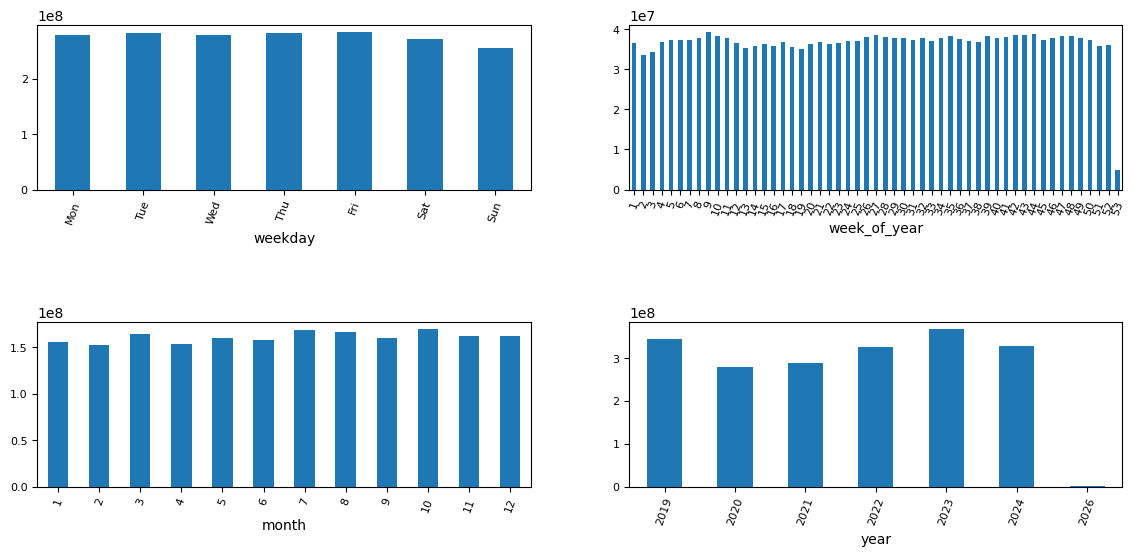

In [416]:
#Create summary plots over weekdays, week of year, months and years
import matplotlib.pyplot as plt

timeMetrics = ['weekday','week_of_year', 'month', 'year']
weekday_map= {
    0: 'Mon',
    1: 'Tue',
    2: 'Wed',
    3: 'Thu',
    4: 'Fri',
    5: 'Sat',
    6: 'Sun'
}

fig, axs = plt.subplots(2, 2, figsize = (14,6))
plt.subplots_adjust(hspace=0.8)    
for i, ax in enumerate(axs.flat):
    metric = timeMetrics[i]
    if metric == 'weekday':
        weekday_series= (
            footfall_19_24.groupby(['weekday'])['estimated_actual_footfall']
            .sum()
            .rename(index= weekday_map)
            .reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']))
        weekday_series.plot.bar(ax=ax, rot=70, fontsize = 8) 
    else:
        footfall_19_24.groupby(metric)['estimated_actual_footfall'].sum().plot.bar(ax=ax, rot=70, fontsize = 8)   

Save the 3 cleaned datasets, ready for analysis:

In [417]:
footfall_clean.to_csv('footfall_cleaned')
footfall_19_24.to_csv('footfall_cleaned_19_24')
footfall_2025.to_csv('footfall_cleaned_2025')

In [418]:
footfall_2025.head(20)

,datestamp,estimated_actual_footfall,estimated_actual_footfall_rolling,year,month,monthday,weekday,week_of_year,Sin_weekday,Cos_weekday,...,daylight_duration,footfall_lag_1,footfall_lag_7,footfall_lag_14,roll_mean_7,roll_std_7,area_Bradford - City Centre,area_Bradford BID,area_Lister Park,area_Met Office - Bradford
2192,2025-01-01,151088.86,NaN,2025,1,1,2,1,8.660254e-01,-0.5,...,27122.144531,133690.66,186023.94,148326.56,182215.454286,37318.376709,0,1,0,0
2193,2025-01-02,171673.62,NaN,2025,1,2,3,1,1.224647e-16,-1.0,...,27203.908203,151088.86,228808.76,158058.86,177224.728571,39021.311159,0,1,0,0
2194,2025-01-03,220639.84,NaN,2025,1,3,4,1,-8.660254e-01,-0.5,...,27291.888672,171673.62,218725.64,167554.03,169062.565714,31726.782949,0,1,0,0
2195,2025-01-04,169561.66,NaN,2025,1,4,5,1,-8.660254e-01,0.5,...,27385.957031,220639.84,201865.08,141366.88,169336.022857,32230.429104,0,1,0,0
2196,2025-01-05,141016.74,NaN,2025,1,5,6,1,-2.449294e-16,1.0,...,27485.986328,169561.66,138833.31,145565.92,164721.248571,28941.440078,0,1,0,0
2197,2025-01-06,110462.71,NaN,2025,1,6,0,2,0.000000e+00,1.0,...,27591.847656,141016.74,167560.79,151846.24,165033.167143,28625.976064,0,1,0,0
2198,2025-01-07,206571.09,NaN,2025,1,7,1,2,8.660254e-01,0.5,...,27703.646484,110462.71,133690.66,195818.96,156876.298571,35172.156163,0,1,0,0
2199,2025-01-08,195219.07,NaN,2025,1,8,2,2,8.660254e-01,-0.5,...,27822.607422,206571.09,151088.86,186023.94,167287.788571,37849.896534,0,1,0,0
2200,2025-01-09,229268.51,NaN,2025,1,9,3,2,1.224647e-16,-1.0,...,27948.650391,195219.07,171673.62,228808.76,173592.104286,38373.663766,0,1,0,0
2201,2025-01-10,213980.51,NaN,2025,1,10,4,2,-8.660254e-01,-0.5,...,28081.453125,229268.51,220639.84,218725.64,181819.945714,43698.833650,0,1,0,0


In [419]:
footfall_2025.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1373 entries, 2192 to 10152
Data columns (total 34 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   datestamp                          1373 non-null   datetime64[ns]
 1   estimated_actual_footfall          1209 non-null   float64       
 2   estimated_actual_footfall_rolling  278 non-null    float64       
 3   year                               1373 non-null   int64         
 4   month                              1373 non-null   int64         
 5   monthday                           1373 non-null   int64         
 6   weekday                            1373 non-null   int64         
 7   week_of_year                       1373 non-null   int64         
 8   Sin_weekday                        1373 non-null   float64       
 9   Cos_weekday                        1373 non-null   float64       
 10  Sin_monthday                       13